# WikiArt Inpainting

In [1]:
from pathlib import Path

repo_dir = Path('/content/unsupervised-learning')
branch_name = 'repoiory-cleaning-up'

if not repo_dir.exists():
    !git clone -b {branch_name} https://github.com/adamzsl/unsupervised-learning.git

%cd /content/unsupervised-learning
!pip install -r requirements.txt

Cloning into 'unsupervised-learning'...
remote: Enumerating objects: 251, done.
remote: Counting objects: 100% (251/251), done.
remote: Compressing objects: 100% (185/185), done.
remote: Total 251 (delta 102), reused 172 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (251/251), 15.90 MiB | 16.87 MiB/s, done.
Resolving deltas: 100% (102/102), done.
/content/unsupervised-learning
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 77.9 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.3.2
    Uninstalling python-box-7.3.2:
      Successfully uninstalled python-box-7.3.2


In [2]:
import os

os.environ["COMET_API_KEY"] = "API"

In [3]:
from pathlib import Path
import pickle

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.utils import load_config, set_seed
from src.dataset import (
    DatasetSplits,
    WikiArtMaskedDataset,
    create_dataloaders,
    load_wikiart_splits,
)
from src.autoencoder import ConvAutoencoder, AutoencoderConfig, extract_embeddings
from src.clusterizer import cluster_embeddings
from src.inpainter import SimpleUNet, InpaintConfig
from src.inpainter import inpaint_step
from comet_ml import Experiment

config = load_config('config.yaml')
set_seed(config['training']['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

experiment = None
exp_cfg = config.get('experiment', {})
if exp_cfg.get('use_comet', False):
    experiment = Experiment(
        project_name=exp_cfg.get('project_name', 'wikiart-inpainting'),
        workspace=exp_cfg.get('workspace') or None,
        auto_param_logging=False,
        auto_metric_logging=False,
        auto_output_logging='simple',
)
    experiment.set_name('wikiart-inpainting-colab')
    experiment.log_parameters({
        'data.image_size': config['data']['image_size'],
        'data.batch_size': config['data']['batch_size'],
        'damage.mask_type': config['damage']['mask_type'],
        'encoder.latent_dim': config['encoder']['latent_dim'],
        'inpainting.base_channels': config['inpainting']['base_channels'],
    })
    print('Comet experiment initialized')

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: keras, sklearn, tensorflow, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.


Device: cuda


COMET ERROR: The given API key 'API' is invalid on 'www.comet.com', please check it against the dashboard. Your experiment will not be logged 
For more details, please refer to: https://www.comet.com/docs/v2/api-and-sdk/python-sdk/warnings-errors/


Comet experiment initialized


In [12]:
print(config['encoder']['latent_dim'])

128


## 1. Wczytanie danych WikiArt

In [5]:
data_cfg = config['data']
mask_cfg = config['damage']

splits = load_wikiart_splits(
    data_cfg['dataset_name'],
    train_split=data_cfg['train_split'],
    val_split=data_cfg['val_split'],
    test_split=data_cfg['test_split'],
    seed=config['training']['seed'],
)

MAX_TRAIN = 5000
MAX_VAL = int(MAX_TRAIN/5)
MAX_TEST = int(MAX_TRAIN/5)

splits = DatasetSplits(
    train=splits.train.select(range(min(MAX_TRAIN, len(splits.train)))),
    val=splits.val.select(range(min(MAX_VAL, len(splits.val)))),
    test=splits.test.select(range(min(MAX_TEST, len(splits.test)))),
)

train_loader, val_loader, test_loader = create_dataloaders(
    splits,
    image_size=data_cfg['image_size'],
    mask_type=mask_cfg['mask_type'],
    batch_size=data_cfg['batch_size'],
    num_workers=data_cfg['num_workers'],
    max_damage_ratio=mask_cfg['max_damage_ratio'],
    min_mask_size=mask_cfg['min_mask_size'],
    max_mask_size=mask_cfg['max_mask_size'],
    brush_width=mask_cfg['brush_width'],
    num_strokes=mask_cfg['num_strokes'],
)

print('Train/Val/Test:', len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))


Train/Val/Test: 5000 1000 1000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 2. Trening autoenkodera (ekstrakcja cech)
Autoenkoder służy do uzyskania reprezentacji obrazu, które później klasteryzujemy.


In [ ]:
auto_cfg = AutoencoderConfig(
    input_channels=3,
    latent_dim=config['encoder']['latent_dim'],
    image_size=data_cfg['image_size'],
)

autoencoder = ConvAutoencoder(auto_cfg).to(device)
autoencoder_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=config['encoder']['learning_rate'])
criterion = nn.L1Loss()

EPOCHS = 5
for epoch in range(1, EPOCHS + 1):
    autoencoder.train()
    train_loss = 0.0
    for images, _, _, _ in tqdm(train_loader, desc=f'Train {epoch}/{EPOCHS}'):
        images = images.to(device)
        autoencoder_optimizer.zero_grad(set_to_none=True)
        recon, _ = autoencoder(images)
        loss = criterion(recon, images)
        loss.backward()
        autoencoder_optimizer.step()
        train_loss += loss.item() * images.size(0)

    train_loss /= max(1, len(train_loader.dataset))
    print(f'Epoch {epoch}: train_loss={train_loss:.4f}')

    if experiment is not None:
        experiment.log_metric('autoencoder_train_loss', train_loss, step=epoch)

Path('models').mkdir(exist_ok=True)
torch.save(autoencoder.state_dict(), 'models/autoencoder.pth')

Train 1/5: 100%|██████████| 157/157 [00:37<00:00,  4.22it/s]


Epoch 1: train_loss=0.1648


Train 2/5: 100%|██████████| 157/157 [00:30<00:00,  5.16it/s]


Epoch 2: train_loss=0.1246


Train 3/5: 100%|██████████| 157/157 [00:29<00:00,  5.35it/s]


Epoch 3: train_loss=0.1107


Train 4/5: 100%|██████████| 157/157 [00:30<00:00,  5.14it/s]


Epoch 4: train_loss=0.1022


Train 5/5: 100%|██████████| 157/157 [00:29<00:00,  5.34it/s]


Epoch 5: train_loss=0.0972


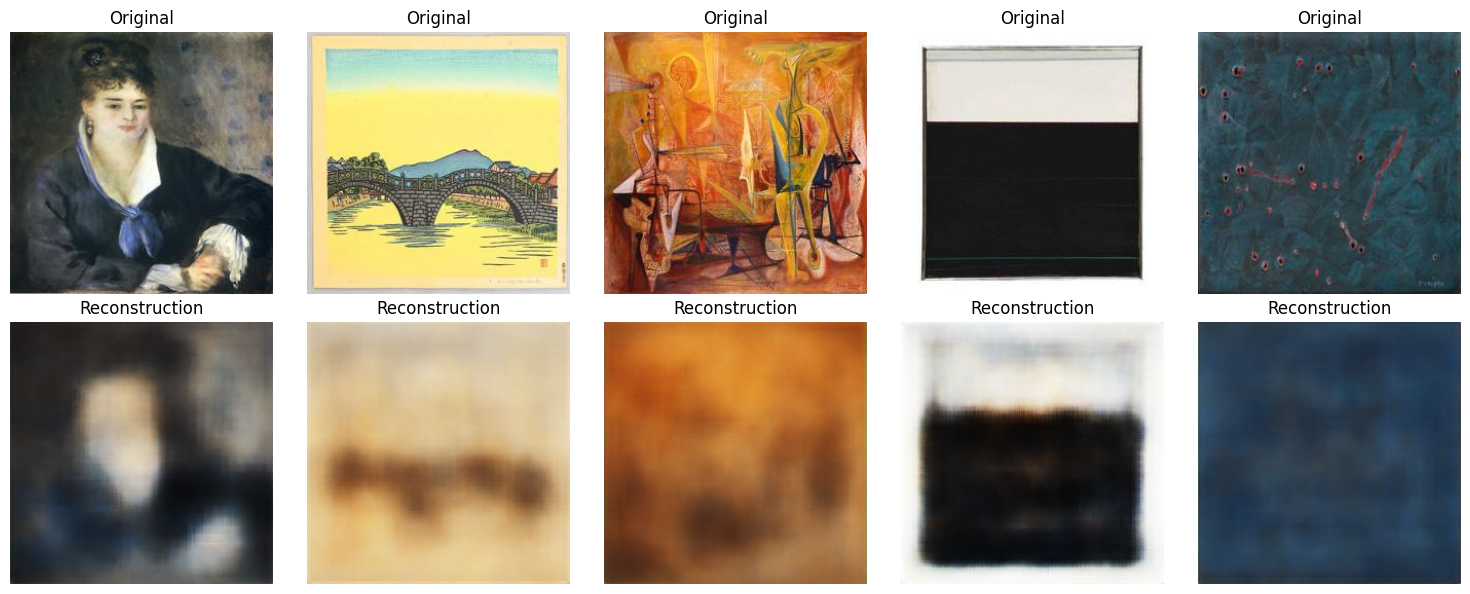

In [7]:
import torch
import matplotlib.pyplot as plt

auto_cfg = AutoencoderConfig(
    input_channels=3,
    latent_dim=config['encoder']['latent_dim'],
    image_size=data_cfg['image_size'],
)

autoencoder = ConvAutoencoder(auto_cfg).to(device)
autoencoder.load_state_dict(torch.load('models/autoencoder.pth', map_location=device))
autoencoder.eval()

N = 5  #liczba obrazów do pokazania

with torch.no_grad():
    images, _, _, _ = next(iter(val_loader))
    images = images.to(device)
    recon, _ = autoencoder(images)

images = images.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2, N, figsize=(3 * N, 6))

for i in range(N):
    # oryginał
    img = images[i].permute(1, 2, 0).clamp(0, 1)
    axes[0, i].imshow(img)
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    # rekonstrukcja
    rec = recon[i].permute(1, 2, 0).clamp(0, 1)
    axes[1, i].imshow(rec)
    axes[1, i].set_title("Reconstruction")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


## 3. Ekstrakcja embeddingów i klasteryzacja
Z embeddingów tworzymy klastry, które wykorzystamy do fine-tuningu inpaintera.


In [8]:
embedding_loader = DataLoader(
    WikiArtMaskedDataset(
        splits.train,
        image_size=data_cfg['image_size'],
        mask_type=mask_cfg['mask_type'],
        max_damage_ratio=mask_cfg['max_damage_ratio'],
        min_mask_size=mask_cfg['min_mask_size'],
        max_mask_size=mask_cfg['max_mask_size'],
        brush_width=mask_cfg['brush_width'],
        num_strokes=mask_cfg['num_strokes'],
    ),
    batch_size=data_cfg['batch_size'],
    shuffle=False,
    num_workers=data_cfg['num_workers'],
)

autoencoder.eval()
embeddings = extract_embeddings(autoencoder, embedding_loader, device).numpy()

labels, artifacts = cluster_embeddings(
    embeddings,
    method=config['clustering']['method'],
    n_clusters=config['clustering']['n_clusters'],
)

np.save('models/train_cluster_labels.npy', labels)
with open('models/cluster_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Cluster labels:', np.unique(labels))


Cluster labels: [0 1 2 3 4 5 6 7]


## 4. Trening bazowego modelu inpainting
Najpierw uczymy model na całym zbiorze, a potem możemy go dostroić per-klaster.


In [9]:
inpaint_model = SimpleUNet(InpaintConfig(base_channels=config['inpainting']['base_channels'])).to(device)
inpaint_optimizer = torch.optim.Adam(inpaint_model.parameters(), lr=1e-3)

INPAINT_EPOCHS = 5

if len(train_loader.dataset) == 0:
    raise ValueError('Train loader is empty. Increase MAX_TRAIN or check dataset loading.')

for epoch in range(1, INPAINT_EPOCHS + 1):
    inpaint_model.train()
    epoch_loss = 0.0
    for batch in tqdm(train_loader, desc=f'Inpaint {epoch}/{INPAINT_EPOCHS}'):
        inpaint_optimizer.zero_grad(set_to_none=True)
        loss_dict = inpaint_step(inpaint_model, batch, device)
        loss = loss_dict['loss']
        loss.backward()
        inpaint_optimizer.step()
        epoch_loss += loss.item() * batch[0].size(0)

    epoch_loss /= max(1, len(train_loader.dataset))
    print(f'Epoch {epoch}: loss={epoch_loss:.4f}')

    if experiment is not None:
        experiment.log_metric('inpaint_train_loss', epoch_loss, step=epoch)

torch.save(inpaint_model.state_dict(), 'models/inpaint_base.pth')

Inpaint 1/5:   0%|          | 0/157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Inpaint 1/5: 100%|██████████| 157/157 [00:44<00:00,  3.51it/s]


Epoch 1: loss=0.0057


Inpaint 2/5: 100%|██████████| 157/157 [00:45<00:00,  3.46it/s]


Epoch 2: loss=0.0046


Inpaint 3/5: 100%|██████████| 157/157 [00:44<00:00,  3.54it/s]


Epoch 3: loss=0.0043


Inpaint 4/5: 100%|██████████| 157/157 [00:44<00:00,  3.51it/s]


Epoch 4: loss=0.0040


Inpaint 5/5: 100%|██████████| 157/157 [00:44<00:00,  3.56it/s]

Epoch 5: loss=0.0039


## 5. Fine-tuning per klaster

In [10]:
from collections import defaultdict

cluster_indices = defaultdict(list)
for idx, label in enumerate(labels):
    cluster_indices[int(label)].append(idx)

CLUSTER_EPOCHS = 2
MIN_CLUSTER_SIZE = 200

for cluster_id, indices in cluster_indices.items():
    if len(indices) < MIN_CLUSTER_SIZE:
        print(f'Skip cluster {cluster_id} (size={len(indices)})')
        continue

    subset = splits.train.select(indices)
    cluster_ds = WikiArtMaskedDataset(
        subset,
        image_size=data_cfg['image_size'],
        mask_type=mask_cfg['mask_type'],
        max_damage_ratio=mask_cfg['max_damage_ratio'],
        min_mask_size=mask_cfg['min_mask_size'],
        max_mask_size=mask_cfg['max_mask_size'],
        brush_width=mask_cfg['brush_width'],
        num_strokes=mask_cfg['num_strokes'],
    )
    cluster_loader = DataLoader(
        cluster_ds,
        batch_size=data_cfg['batch_size'],
        shuffle=True,
        num_workers=data_cfg['num_workers'],
    )

    cluster_model = SimpleUNet(InpaintConfig(base_channels=config['inpainting']['base_channels'])).to(device)
    cluster_model.load_state_dict(inpaint_model.state_dict())

    cluster_optimizer = torch.optim.Adam(cluster_model.parameters(), lr=1e-4)

    for epoch in range(1, CLUSTER_EPOCHS + 1):
        cluster_model.train()
        epoch_loss = 0.0
        for batch in tqdm(cluster_loader, desc=f'Cluster {cluster_id} ({epoch}/{CLUSTER_EPOCHS})'):
            cluster_optimizer.zero_grad(set_to_none=True)
            loss_dict = inpaint_step(cluster_model, batch, device)
            loss = loss_dict['loss']
            loss.backward()
            cluster_optimizer.step()
            epoch_loss += loss.item() * batch[0].size(0)

        epoch_loss /= max(1, len(cluster_loader.dataset))
        print(f'Cluster {cluster_id} Epoch {epoch}: loss={epoch_loss:.4f}')

        if experiment is not None:
            experiment.log_metric(f'inpaint_cluster_{cluster_id}_loss', epoch_loss, step=epoch)

    torch.save(cluster_model.state_dict(), f'models/inpaint_cluster_{cluster_id}.pth')

Cluster 5 (1/2): 100%|██████████| 9/9 [00:03<00:00,  2.59it/s]


Cluster 5 Epoch 1: loss=0.0041


Cluster 5 (2/2): 100%|██████████| 9/9 [00:03<00:00,  2.57it/s]


Cluster 5 Epoch 2: loss=0.0044


Cluster 7 (1/2): 100%|██████████| 27/27 [00:09<00:00,  2.99it/s]


...

Cluster 6 Epoch 2: loss=0.0039


Cluster 3 (1/2): 100%|██████████| 20/20 [00:06<00:00,  3.04it/s]


Cluster 3 Epoch 1: loss=0.0043


Cluster 3 (2/2): 100%|██████████| 20/20 [00:06<00:00,  2.95it/s]

Cluster 3 Epoch 2: loss=0.0033
Skip cluster 0 (size=46)


## 6. Szybki test inpaintera
Użyj modelu bazowego lub jednego z modeli klastrowych.


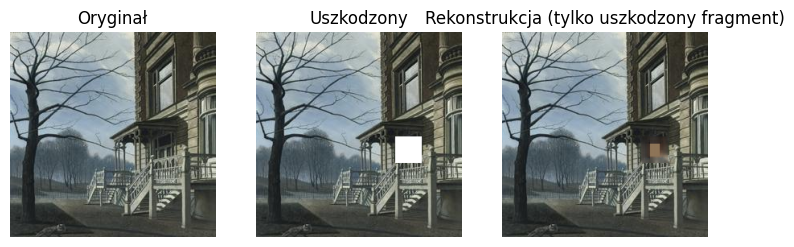

In [17]:
import torch
import matplotlib.pyplot as plt

sample_ds = WikiArtMaskedDataset(
    splits.test,
    image_size=data_cfg['image_size'],
    mask_type=mask_cfg['mask_type'],
    max_damage_ratio=mask_cfg['max_damage_ratio'],
    min_mask_size=mask_cfg['min_mask_size'],
    max_mask_size=mask_cfg['max_mask_size'],
    brush_width=mask_cfg['brush_width'],
    num_strokes=mask_cfg['num_strokes'],
)

image, mask, masked, _ = sample_ds[0]

inpaint_model.eval()

with torch.no_grad():
    output = inpaint_model(
        masked.unsqueeze(0).to(device),
        mask.unsqueeze(0).to(device)
    ).clamp(0, 1)

image_ = image.unsqueeze(0).to(device)
mask_ = mask.unsqueeze(0).to(device)
composited = mask_ * output + (1-mask_) * image_


step = 0

experiment.log_image(
    image.permute(1, 2, 0).cpu().numpy(),
    name="oryginal",
    step=step
)

experiment.log_image(
    masked.permute(1, 2, 0).cpu().numpy(),
    name="uszkodzony",
    step=step
)

experiment.log_image(
    composited.squeeze(0).permute(1, 2, 0).cpu().numpy(),
    name="rekonstrukcja_tylko_maska",
    step=step
)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title('Oryginał')

axes[1].imshow(masked.permute(1, 2, 0))
axes[1].set_title('Uszkodzony')

axes[2].imshow(composited.squeeze(0).cpu().permute(1, 2, 0))
axes[2].set_title('Rekonstrukcja (tylko uszkodzony fragment)')

for ax in axes:
    ax.axis('off')

plt.show()

##8. Pobranie modelu

In [18]:
import shutil
from google.colab import files

shutil.make_archive('models', 'zip', 'models')
files.download('models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>